In [1]:
# @title Setup smoke test (run this once at home before the tutorial!)
try:
    from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache  # noqa
    import ssm  # noqa
    print("✅ Setup complete.")
except Exception as e:
    print("❌ Setup FAILED:", e)
    raise

/Users/kchen/Workspace/ccnss2026-neural-data-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete.


# CCNSS 2026 — Session 2: Dynamics and States

**Theme:** From population activity to dynamics and discrete states.

Three modules on the NLB MC_Maze dataset:
- **2A** — PCA on population activity
- **2B** — Linear Dynamical Systems (`ssm`)
- **2C** — Hidden Markov Models (`ssm`)
- **Wrap-up** — Where the field is going (LFADS, CEBRA, MARBLE)

In [3]:
# @title Setup (run once)
import sys; sys.path.insert(0, "/content/ccnss2026-neural-data-analysis")

import numpy as np, matplotlib.pyplot as plt
from ccnss_helpers import data, plotting, save_checkpoint, load_or_compute
print("✅ Setup complete.")

✅ Setup complete.


In [4]:
mm = data.load_mc_maze_small()
binned = mm["binned_spikes"]   # (trials, bins, neurons)
dirs = mm["trial_directions"]  # (trials,)
hand = mm["hand_trajectory"]   # (trials, bins, 2)
print(binned.shape, "directions:", np.unique(dirs))

(100, 140, 107) directions: [ 2  3  4  6  7  8 10 11 12]


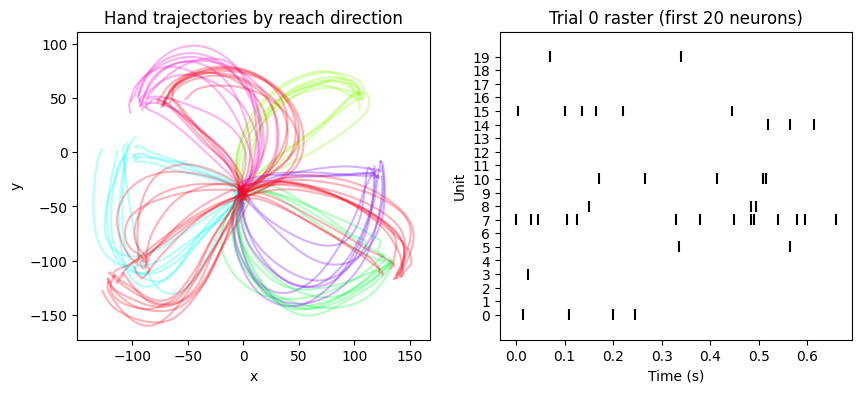

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for d in np.unique(dirs):
    m = dirs == d
    axes[0].plot(hand[m, :, 0].T, hand[m, :, 1].T, color=plt.cm.hsv(d / 8), alpha=0.3)
axes[0].set_title("Hand trajectories by reach direction"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
# Raster of one trial.
trial0_spikes = {n: np.where(binned[0, :, n] > 0)[0] * mm["bin_size_s"] for n in range(20)}
plotting.plot_raster(trial0_spikes, ax=axes[1])
axes[1].set_title("Trial 0 raster (first 20 neurons)");

## Module 2A — PCA on population activity

We trial-average per reach direction, stack as (conditions × time) × neurons, fit PCA,
and visualize the top 3 PC trajectories.

**Key idea:** if all neurons fired independently, you'd need N dimensions. The fact that
just 3 capture most of the variance means the population lives on a low-dimensional manifold.

In [6]:
def trial_average_per_direction(binned, dirs):
    """Returns (n_directions, n_bins, n_neurons) average rates."""
    unique_dirs = np.unique(dirs)
    return np.stack([binned[dirs == d].mean(axis=0) for d in unique_dirs])

avg = trial_average_per_direction(binned, dirs)   # (n_dir, n_bins, n_neurons)
print(avg.shape)

(9, 140, 107)


In [7]:
# EXERCISE: fit PCA on the trial-averaged data and project to the top components
from sklearn.decomposition import PCA

n_dir, n_bins, n_neurons = avg.shape
X = avg.reshape(n_dir * n_bins, n_neurons)
pca = PCA(n_components=10).fit(X)
Z = pca.transform(X).reshape(n_dir, n_bins, 10)
print("Explained variance ratio (top 5):", pca.explained_variance_ratio_[:5])

Explained variance ratio (top 5): [0.05254225 0.04333163 0.03954938 0.03508727 0.03047878]


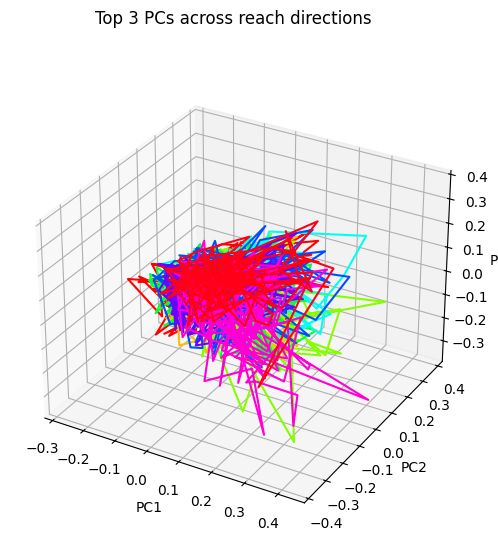

In [8]:
plotting.plot_latents_3d(Z[:, :, :3])
plt.suptitle("Top 3 PCs across reach directions");

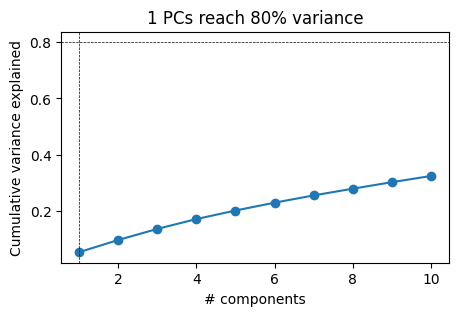

In [9]:
# EXERCISE: plot cumulative variance explained; how many PCs reach 80%?
cum = np.cumsum(pca.explained_variance_ratio_)
k80 = (cum >= 0.8).argmax() + 1
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(1, len(cum) + 1), cum, "o-")
ax.axhline(0.8, color="k", lw=0.5, ls="--"); ax.axvline(k80, color="k", lw=0.5, ls="--")
ax.set_xlabel("# components"); ax.set_ylabel("Cumulative variance explained")
ax.set_title(f"{k80} PCs reach 80% variance");

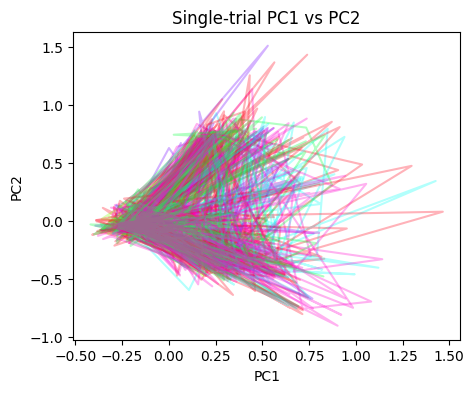

In [10]:
# CUTTABLE: project single trials into the trial-averaged PCA basis
Z_single = pca.transform(binned.reshape(-1, n_neurons)).reshape(binned.shape[0], n_bins, -1)
fig, ax = plt.subplots(figsize=(5, 4))
for t in range(min(20, binned.shape[0])):
    ax.plot(Z_single[t, :, 0], Z_single[t, :, 1], alpha=0.3, color=plt.cm.hsv(dirs[t] / 8))
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("Single-trial PC1 vs PC2");

In [11]:
save_checkpoint("module_2A", avg=avg, Z=Z, evr=pca.explained_variance_ratio_,
                components=pca.components_, mean=pca.mean_)
print("✅ 2A checkpoint saved.")

✅ 2A checkpoint saved.


## Module 2B — Linear Dynamical Systems

PCA gives us a low-D snapshot but ignores time. An LDS adds a transition model:

$$z_{t+1} = A z_t + \epsilon_t, \quad y_t = C z_t + \nu_t$$

We fit one with Linderman's `ssm` and compare latents to PCA. Then simulate from the fit.

> **Aside on GPFA:** structurally similar but puts a Gaussian Process prior on latents → smoother trajectories. Same conceptual goal; different smoothness regularizer.

In [12]:
# 2-minute tour of ssm: fit a tiny 2D LDS on toy data so the API is familiar.
import ssm
toy_T, toy_D, toy_N = 200, 2, 10
toy_lds = ssm.LDS(N=toy_N, D=toy_D, emissions="poisson")
toy_z, toy_y = toy_lds.sample(T=toy_T)
toy_fit = ssm.LDS(N=toy_N, D=toy_D, emissions="poisson")
toy_fit.fit(toy_y, num_iters=20, verbose=0)
print("Toy LDS fitted successfully. API: .sample(), .fit(), .most_likely_states() etc.")

Toy LDS fitted successfully. API: .sample(), .fit(), .most_likely_states() etc.


In [13]:
# EXERCISE: fit a D=6 LDS to single-trial spike counts
D_lat = 6
# ssm expects list of (T, N) arrays for trial-structured data
trials = [binned[i] for i in range(binned.shape[0])]
lds = ssm.LDS(N=binned.shape[2], D=D_lat, emissions="poisson")
elbos, q = lds.fit(trials, num_iters=30, verbose=0)
print("Final ELBO:", elbos[-1])

Final ELBO: -144670.1341105754


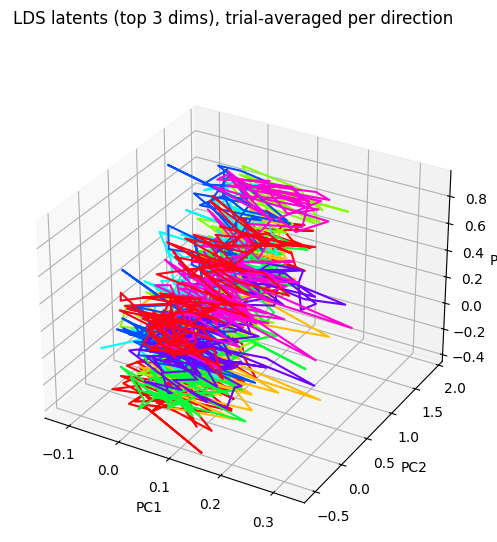

In [14]:
latents = np.stack(q.mean_continuous_states)  # (trials, bins, D)
avg_latents = trial_average_per_direction(latents, dirs)   # (n_dir, bins, D)
plotting.plot_latents_3d(avg_latents[:, :, :3])
plt.suptitle("LDS latents (top 3 dims), trial-averaged per direction");

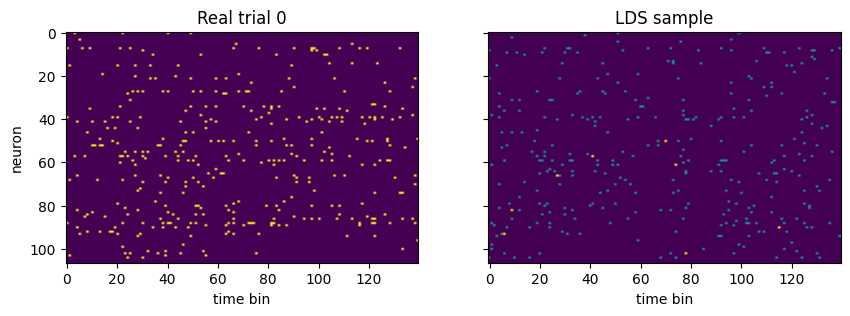

In [15]:
# EXERCISE: simulate from the fitted LDS and compare PSTH to the real data
sim_z, sim_y = lds.sample(T=binned.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].imshow(binned[0].T, aspect="auto"); axes[0].set_title("Real trial 0")
axes[1].imshow(sim_y.T, aspect="auto"); axes[1].set_title("LDS sample")
for a in axes: a.set_xlabel("time bin")
axes[0].set_ylabel("neuron");

  0%|          | 0/5 [00:00<?, ?it/s]

ELBO: -3721.8:   0%|          | 0/5 [00:00<?, ?it/s]

ELBO: -1553.1:   0%|          | 0/5 [00:00<?, ?it/s]

ELBO: -1546.9:   0%|          | 0/5 [00:00<?, ?it/s]

ELBO: -1559.2:   0%|          | 0/5 [00:00<?, ?it/s]

...

ELBO: -1340.5:   0%|          | 0/5 [00:00<?, ?it/s]

ELBO: -1340.5:  60%|██████    | 3/5 [00:00<00:00, 29.58it/s]

ELBO: -1361.0:  60%|██████    | 3/5 [00:00<00:00, 29.58it/s]

ELBO: -1353.1:  60%|██████    | 3/5 [00:00<00:00, 29.58it/s]

ELBO: -1353.1: 100%|██████████| 5/5 [00:00<00:00, 31.22it/s]

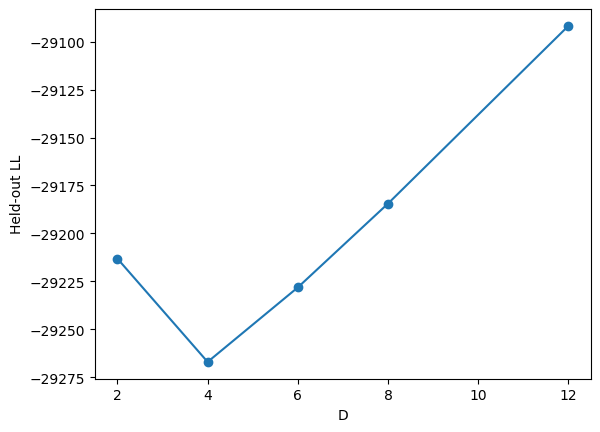

In [16]:
# CUTTABLE: vary D, plot held-out log-likelihood
train, test = trials[:80], trials[80:]
lls = []
for D in [2, 4, 6, 8, 12]:
    m = ssm.LDS(N=binned.shape[2], D=D, emissions="poisson")
    m.fit(train, num_iters=15, verbose=0)  # returns (elbos, q) but we ignore
    lls.append(sum(m.approximate_posterior([t], num_iters=5)[0][-1] for t in test))
plt.plot([2, 4, 6, 8, 12], lls, "o-"); plt.xlabel("D"); plt.ylabel("Held-out LL");

In [17]:
save_checkpoint("module_2B", latents=latents, avg_latents=avg_latents)
print("✅ 2B checkpoint saved.")

✅ 2B checkpoint saved.


## Module 2C — Hidden Markov Models

Instead of continuous latents, we now ask: are there **discrete states** (e.g. baseline,
preparation, movement, hold)? Fit a Poisson-HMM with `ssm` and visualize the state sequence aligned to movement onset.

In [18]:
# EXERCISE: fit a 4-state Poisson HMM
K = 4
hmm = ssm.HMM(K=K, D=binned.shape[2], observations="poisson")
hmm.fit(trials, num_iters=40, verbose=0)
print("HMM fit complete.")

HMM fit complete.


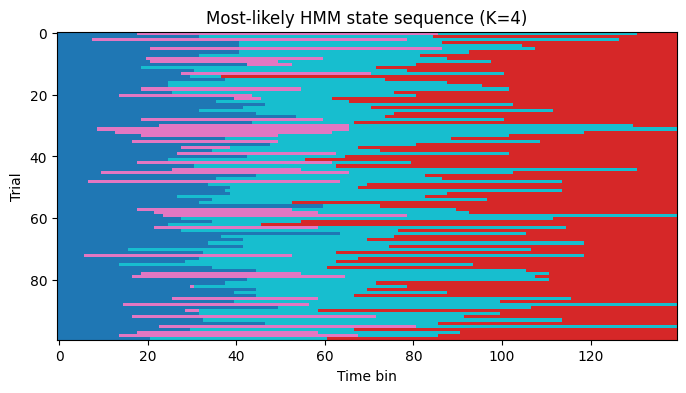

In [19]:
states = np.stack([hmm.most_likely_states(t) for t in trials])
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(states, aspect="auto", cmap="tab10", interpolation="nearest")
ax.set_xlabel("Time bin"); ax.set_ylabel("Trial")
ax.set_title(f"Most-likely HMM state sequence (K={K})");

In [20]:
# EXERCISE: refit with K=3 and K=6; interpret what the states correspond to
for K_try in [3, 6]:
    h = ssm.HMM(K=K_try, D=binned.shape[2], observations="poisson")
    h.fit(trials, num_iters=30, verbose=0)
    print(f"K={K_try}, mean dwell time per state:",
          [np.mean(np.diff(np.where(np.diff(h.most_likely_states(trials[0])) != 0)[0])) for _ in [0]])

K=3, mean dwell time per state: [54.0]


K=6, mean dwell time per state: [55.0]


In [21]:
# CUTTABLE: SLDS (Switching LDS) = 2B + 2C unified
slds = ssm.SLDS(N=binned.shape[2], K=4, D=6, emissions="poisson")
slds.fit(trials[:50], num_iters=20, verbose=0)
print("SLDS fit complete — see ssm docs for posterior inference.")

SLDS fit complete — see ssm docs for posterior inference.


## Where the field is going

- **LFADS** — sequential VAE for neural dynamics. Pandarinath et al. 2018.
- **CEBRA** — contrastive embeddings constrained by behavior. Schneider et al. 2023.
- **MARBLE** — geometric/manifold methods for neural manifolds. Gosztolai et al. 2024.

Code-free — but worth bookmarking. See slide for paper + GitHub links.

In [22]:
# 🎉 End of Session 2
print("Session 2 complete! Resources and further reading in the slide deck.")

Session 2 complete! Resources and further reading in the slide deck.
